In [1]:
# ambiente anaconda
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/orange3/bin/python


In [2]:
# versão do python
print(sys.version)

3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]


In [3]:
#!pip install Orange3

<font color="green"># ATUALIZAÇÃO ABRIL/2025


Após instalar o Orange, reinicie o ambiente de execução. Rode a próxima célula sozinha e aguarde a reconexão:</font>

In [4]:
#exit()

In [5]:
import Orange
Orange.__version__

'3.39.0'

---

Reconecte ao Drive.

In [6]:
# from google.colab import drive
# drive.mount('/content/drive')
import os
# DRIVE_DIRECTORY = "curso_ml"
# DRIVE_DIRECTORY = os.path.join("/content/drive/MyDrive", DRIVE_DIRECTORY)

In [7]:
#!pip install seaborn
# https://seaborn.pydata.org/installing.html
# ctlr + : comentar

# Regras
Para gerar regras, nós precisamos começar com o arquivo com os dados originais, `cov_types.csv`, que deve estar salvo na sua pasta do Drive.

Primeiro recarregue esse arquivo com o Pandas.

In [8]:
import pickle

from collections import Counter

import pandas as pd
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
DRIVE_DIRECTORY_fonte ='../../2-3-Classificacao/Exercicio_Faltante_Classificacao'
base = pd.read_csv(os.path.join(DRIVE_DIRECTORY_fonte, 'cov_types_reduzido_exer3.csv'))
base.tail(15)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type
9985,3246.0,309.0,15.0,430.0,119.0,3578.0,177.0,229.0,192.0,1894.0,2,30,Spruce/Fir
9986,3199.0,293.0,12.0,466.0,81.0,876.0,185.0,237.0,192.0,700.0,2,22,Lodgepole Pine
9987,3388.0,94.0,12.0,607.0,155.0,1848.0,239.0,221.0,110.0,1790.0,0,34,Krummholz
9988,3210.0,43.0,8.0,0.0,0.0,124.0,222.0,223.0,136.0,830.0,1,15,Lodgepole Pine
9989,3317.0,63.0,10.0,30.0,-2.0,2873.0,229.0,221.0,124.0,1806.0,2,37,Krummholz
9990,2788.0,20.0,9.0,30.0,2.0,3555.0,214.0,221.0,143.0,2984.0,0,22,Spruce/Fir
9991,2899.0,84.0,17.0,85.0,21.0,1176.0,242.0,208.0,90.0,1664.0,0,29,Lodgepole Pine
9992,3517.0,270.0,5.0,459.0,70.0,1445.0,207.0,241.0,173.0,1937.0,1,39,Krummholz
9993,2942.0,351.0,10.0,391.0,29.0,5337.0,203.0,224.0,159.0,2105.0,0,28,Lodgepole Pine
9994,2055.0,327.0,19.0,30.0,14.0,532.0,169.0,215.0,183.0,684.0,3,13,Douglas-fir


sem OneHotEncoder nas colunas  Wilderness_Area e Soil_Type. 

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

### Agora, lembre-se que a coluna com a classe deve ser indicada pelo prefixo `c#`. Então, vamos renomear a coluna `Cover_Type` para ficar neste formato.

In [10]:
# atributo objetivo: c#Cover_Type

base.rename(columns={"Cover_Type": "c#Cover_Type"}, inplace=True)
base

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,c#Cover_Type
0,2767.0,66.0,17.0,210.0,18.0,1190.0,234.0,204.0,96.0,2251.0,2,30,Lodgepole Pine
1,2724.0,160.0,19.0,60.0,4.0,1350.0,236.0,240.0,127.0,2514.0,2,16,Lodgepole Pine
2,2360.0,65.0,7.0,127.0,21.0,1377.0,227.0,226.0,134.0,339.0,3,5,Ponderosa Pine
3,2995.0,45.0,4.0,285.0,30.0,5125.0,221.0,231.0,146.0,5706.0,0,11,Lodgepole Pine
4,2400.0,106.0,27.0,150.0,63.0,342.0,253.0,196.0,51.0,811.0,2,3,Ponderosa Pine
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2917.0,90.0,9.0,247.0,25.0,4095.0,235.0,225.0,121.0,3901.0,0,28,Lodgepole Pine
9996,3015.0,38.0,8.0,361.0,74.0,4846.0,220.0,223.0,138.0,1611.0,0,28,Lodgepole Pine
9997,3052.0,79.0,19.0,90.0,11.0,1003.0,241.0,203.0,85.0,1490.0,2,22,Spruce/Fir
9998,2958.0,58.0,6.0,319.0,19.0,2468.0,225.0,227.0,137.0,2280.0,0,28,Lodgepole Pine


Salve o arquivo modificado. Como você só vai utilizar este arquivo neste exercício, não precisa salvar no Drive.

In [11]:
base.to_csv('cov_types_orange_exe6.csv', index=False)

## Gere uma instância da classe `Orange.data.Table` informando o arquivo `csv` contendo os dados.

novo artigo

In [12]:
base = Orange.data.Table('cov_types_orange_exe6.csv')

Exiba o domínio desta base.

In [13]:
base.domain

[Elevation, Aspect, Slope, Horizontal_Distance_To_Hydrology, Vertical_Distance_To_Hydrology, Horizontal_Distance_To_Roadways, Hillshade_9am, Hillshade_Noon, Hillshade_3pm, Horizontal_Distance_To_Fire_Points, Wilderness_Area, Soil_Type | Cover_Type]

In [14]:
# nomes dos atributos e a | junto com a classe Cover_Type

In [15]:
base[:5]

[[2767.0, 66.0, 17.0, 210.0, 18.0, ... | Lodgepole Pine],
 [2724.0, 160.0, 19.0, 60.0, 4.0, ... | Lodgepole Pine],
 [2360.0, 65.0, 7.0, 127.0, 21.0, ... | Ponderosa Pine],
 [2995.0, 45.0, 4.0, 285.0, 30.0, ... | Lodgepole Pine],
 [2400.0, 106.0, 27.0, 150.0, 63.0, ... | Ponderosa Pine]
]

### Utilize o método adequado da biblioteca Orange para separar 25% dos dados da base em um split de teste, e o restante em um split de treinamento. Você pode salvar o resultado da função diretamente nas variáveis dos splits correspondentes, observando que o split de teste é retornado primeiro.

In [16]:
base_test, base_train = Orange.evaluation.testing.sample(base, n=0.25)

Verifique o tamanho desses splits.

In [17]:
len(base_train), len(base_test) # base de dados de treinamento e de teste

(7500, 2500)

In [18]:
base_train[:5]

[[3417.0, 240.0, 28.0, 443.0, 162.0, ... | Spruce/Fir],
 [2971.0, 94.0, 15.0, 134.0, 26.0, ... | Spruce/Fir],
 [3078.0, 323.0, 9.0, 42.0, 11.0, ... | Spruce/Fir],
 [3011.0, 64.0, 6.0, 808.0, 39.0, ... | Lodgepole Pine],
 [2856.0, 96.0, 5.0, 295.0, 39.0, ... | Lodgepole Pine]
]

In [19]:
base_test[:5]

[[3151.0, 99.0, 12.0, 170.0, -23.0, ... | Lodgepole Pine],
 [2789.0, 122.0, 16.0, 0.0, 0.0, ... | Lodgepole Pine],
 [2609.0, 70.0, 21.0, 134.0, 55.0, ... | Ponderosa Pine],
 [3063.0, 354.0, 7.0, 242.0, 5.0, ... | Spruce/Fir],
 [2955.0, 83.0, 6.0, 30.0, 3.0, ... | Lodgepole Pine]
]

Instancie e ajuste um classificador do tipo `CN2Learner`.

criando as regras abaixo

In [20]:
cn2_classifier = Orange.classification.rules.CN2Learner()
rules = cn2_classifier(base_train)

In [21]:
cn2_classifier

CN2Learner(base_rules=[]base_rules=[])

In [22]:
rules

CN2Classifier(domain=[Elevation, Aspect, Slope, Horizontal_Distance_To_Hydrology, Vertical_Distance_To_Hydrology, Horizontal_Distance_To_Roadways, Hillshade_9am, Hillshade_Noon, Hillshade_3pm, Horizontal_Distance_To_Fire_Points, Wilderness_Area, Soil_Type | Cover_Type]domain=[Elevation, Aspect, Slope, Horizontal_Distance_To_Hydrology, Vertical_Distance_To_Hydrology, Horizontal_Distance_To_Roadways, Hillshade_9am, Hillshade_Noon, Hillshade_3pm, Horizontal_Distance_To_Fire_Points, Wilderness_Area, Soil_Type | Cover_Type],
              ,
              rule_list=[<Orange.classification.rules.Rule at 0x73b5735b37f0>,
               ...]rule_list=[<Orange.classification.rules.Rule at 0x73b5735b37f0>,
               ...])

Observe que, como esta base é maior, o número de regras é bastante elevado:

In [23]:
print(f'Foram criadas {len(rules.rule_list)} regras.')

Foram criadas 1615 regras.


Então, vamos visualizar somente as 10 primeiras regras:

In [24]:
for i, rule in enumerate(rules.rule_list):
    print(rule)
    if i == 10:
        break

IF Horizontal_Distance_To_Roadways>=6468.0 THEN Cover_Type=Lodgepole Pine 
IF Horizontal_Distance_To_Hydrology>=1064.0 AND Elevation>=3368.0 THEN Cover_Type=Krummholz 
IF Horizontal_Distance_To_Fire_Points>=4335.0 AND Hillshade_9am>=254.0 THEN Cover_Type=Aspen 
IF Horizontal_Distance_To_Fire_Points>=4335.0 AND Soil_Type>=37.0 THEN Cover_Type=Spruce/Fir 
IF Elevation>=3334.0 AND Elevation>=3712.0 THEN Cover_Type=Krummholz 
IF Elevation>=3334.0 AND Vertical_Distance_To_Hydrology>=226.0 THEN Cover_Type=Spruce/Fir 
IF Horizontal_Distance_To_Fire_Points>=3273.0 AND Horizontal_Distance_To_Hydrology>=764.0 THEN Cover_Type=Lodgepole Pine 
IF Elevation>=3361.0 AND Hillshade_3pm>=201.0 THEN Cover_Type=Spruce/Fir 
IF Elevation>=3047.0 AND Horizontal_Distance_To_Hydrology>=1140.0 THEN Cover_Type=Lodgepole Pine 
IF Wilderness_Area<=1.0 AND Elevation<=2682.0 AND Aspect>=135.0 THEN Cover_Type=Lodgepole Pine 
IF Horizontal_Distance_To_Fire_Points>=4335.0 AND Hillshade_9am>=248.0 THEN Cover_Type=Lodgep

## Faça predições informando ao algoritmo a base de teste.

In [25]:
y_pred = rules(base_test)
y_pred # previsões do algoritmo

array([6, 4, 4, ..., 6, 4, 6])

Observe que nós podemos recuperar os valores reais através do atributo `Y` de `base_test`.

In [26]:
y_test = base_test.Y # valores reais
y_test

array([4., 4., 5., ..., 4., 4., 6.])

Utilize este valor para calcular a acurácia do modelo.

In [27]:
accuracy_score(y_test, y_pred)

0.6788

In [28]:
print(f'tivemos {accuracy_score(y_test, y_pred)*100:.2f} % de acurácia ou acerto')

tivemos 67.88 % de acurácia ou acerto


Desta vez você deve utilizar a função `confusion_matrix` do `sklearn` para exibir a matriz de confusão no formato de um array. Esta função recebe primeiro os valores reais, depois os valores preditos.

In [29]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 10,   0,   1,   0,  18,   3,   3],
       [  0,   5,   2,   0,   0,   3,   0],
       [  1,   1,  20,   0,  14,  34,   1],
       [  0,   0,   0,  52,   8,   0,  32],
       [ 26,   1,  10,   3, 890,  19, 244],
       [  1,   3,  30,   0,  25,  78,   1],
       [  4,   0,   1,  40, 273,   1, 642]])

In [30]:
#!pip install yellowbrick

In [31]:
# from yellowbrick.classifier import ConfusionMatrix
# cm = ConfusionMatrix(rules)
# cm.fit(X_train, y_train)
# cm.score(X_test, y_test)

### Você pode gerar um gráfico da matriz de confusão similar ao do yellowbrick com a função `sns.heatmap`:

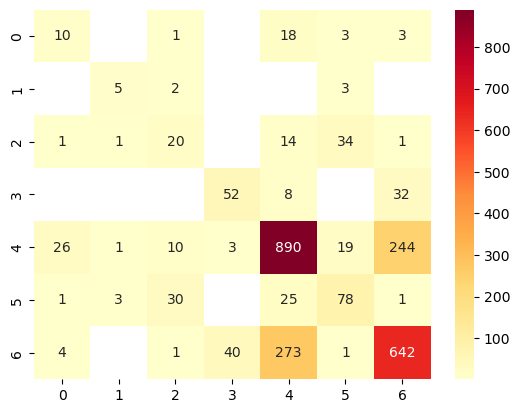

In [32]:
sns.heatmap(cm,
            annot=True, # para exibir as contagens nas células do gráfico
            fmt='d', # para que os valores sejam em formato inteiro
            cmap='YlOrRd', # o mesmo mapa de cor do yellowbrick
            mask = (cm == 0) # não exibe os valores e a cor onde o valor for igual a 0
            );

visualização com mais clareza cada uma das classes, onde as classes 4 e 6 foram as que acertaram mais. 

Exiba o reporte de classificação do modelo.

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.24      0.29      0.26        35
         1.0       0.50      0.50      0.50        10
         2.0       0.31      0.28      0.30        71
         3.0       0.55      0.57      0.56        92
         4.0       0.72      0.75      0.74      1193
         5.0       0.57      0.57      0.57       138
         6.0       0.70      0.67      0.68       961

    accuracy                           0.68      2500
   macro avg       0.51      0.52      0.51      2500
weighted avg       0.68      0.68      0.68      2500



In [34]:
y_test_copy = y_test.copy()

1. Precision (Precisão)
Pergunta: "De todas as vezes que o modelo disse que era Aspen, quantas eram realmente Aspen?"

Foco: Evitar alarmes falsos.

Se a precisão é 0.80, significa que quando o modelo aponta para uma árvore e diz "É Aspen", ele acerta 80% das vezes.

2. Recall (Revocação / Sensibilidade)
Pergunta: "De todas as árvores Aspen que existem de verdade no mato, quantas o modelo conseguiu encontrar?"

Foco: Não deixar passar nada.

Se o recall é 0.60, significa que o modelo só achou 60% das Aspens totais; as outras 40% ele confundiu com outro tipo.

3. F1-Score
O que é: Uma média (harmônica) entre a Precisão e o Recall.

Foco: Equilíbrio.

É a melhor métrica para olhar se você quer um resumo rápido, pois se a Precisão for ótima mas o Recall for péssimo (ou vice-versa), o F1-Score cai.

4. Support (Suporte)
O que é: A quantidade real de exemplos daquela classe no seu conjunto de testes.

Foco: Contexto.

Se o suporte de uma árvore é 10 e de outra é 5000, você sabe que o resultado da primeira não é tão confiável estatisticamente quanto o da segunda.

- ideal precision e recall elevados, como nas classes 4,5 e 6

## Classificador base (majority learner)

Implemente um classificador do tipo `MajorityLearner`.

In [35]:
majority = Orange.classification.MajorityLearner()

Faça predições para a base inteira com base nesse classificador.

In [36]:
y_test = Orange.evaluation.testing.TestOnTestData(base, base, [majority])

In [37]:
y_test

Exiba a acurácia deste classificador.

In [38]:
Orange.evaluation.CA(y_test)

array([0.4847])

### Exiba o número de registros em cada classe na base inteira.

In [39]:
Counter(str(instance.get_class()) for instance in base)

Counter({'Lodgepole Pine': 4847,
         'Spruce/Fir': 3714,
         'Ponderosa Pine': 581,
         'Krummholz': 362,
         'Douglas-fir': 278,
         'Aspen': 163,
         'Cottonwood/Willow': 55})

maiores quantidades nas classes 'Lodgepole Pine': 4847 e 'Spruce/Fir': 3714,

Veja que a base tem 10 mil registros:

In [40]:
len(base)

10000

Isso significa que a classe majoritária, *Lodgepole Pine*, representa $4847/10000=0.4847\%$ dos dados, ou seja, exatamente a acurácia alcançada pelo classificador base do tipo *majority learner*.

In [41]:
# os 0,4847% é o mesmo valor da acurácia Orange.evaluation.CA(y_test),
#registra os outros arquivos onde há o maior número de instâncias, no caso o Lodgepole Pine

---

## renomear as classes

In [42]:
# Supondo que 'base_train' seja sua tabela Orange
nomes_das_classes = base_train.domain.class_var.values

# Para ver a string da primeira previsão:
primeira_previsao = int(y_pred[0])
print(f"O número {primeira_previsao} é a árvore: {nomes_das_classes[primeira_previsao]}")

# Para converter TODAS as previsões em uma lista de strings:
y_pred_strings = [nomes_das_classes[int(i)] for i in y_pred]

O número 6 é a árvore: Spruce/Fir


In [43]:
for rule in rules.rule_list:
    print(rule)

IF Horizontal_Distance_To_Roadways>=6468.0 THEN Cover_Type=Lodgepole Pine 
IF Horizontal_Distance_To_Hydrology>=1064.0 AND Elevation>=3368.0 THEN Cover_Type=Krummholz 
IF Horizontal_Distance_To_Fire_Points>=4335.0 AND Hillshade_9am>=254.0 THEN Cover_Type=Aspen 
IF Horizontal_Distance_To_Fire_Points>=4335.0 AND Soil_Type>=37.0 THEN Cover_Type=Spruce/Fir 
IF Elevation>=3334.0 AND Elevation>=3712.0 THEN Cover_Type=Krummholz 
IF Elevation>=3334.0 AND Vertical_Distance_To_Hydrology>=226.0 THEN Cover_Type=Spruce/Fir 
IF Horizontal_Distance_To_Fire_Points>=3273.0 AND Horizontal_Distance_To_Hydrology>=764.0 THEN Cover_Type=Lodgepole Pine 
IF Elevation>=3361.0 AND Hillshade_3pm>=201.0 THEN Cover_Type=Spruce/Fir 
IF Elevation>=3047.0 AND Horizontal_Distance_To_Hydrology>=1140.0 THEN Cover_Type=Lodgepole Pine 
IF Wilderness_Area<=1.0 AND Elevation<=2682.0 AND Aspect>=135.0 THEN Cover_Type=Lodgepole Pine 
IF Horizontal_Distance_To_Fire_Points>=4335.0 AND Hillshade_9am>=248.0 THEN Cover_Type=Lodgep

In [44]:
nomes_das_classes

('Aspen',
 'Cottonwood/Willow',
 'Douglas-fir',
 'Krummholz',
 'Lodgepole Pine',
 'Ponderosa Pine',
 'Spruce/Fir')

In [45]:
# Acessa a variável de classe e mostra os nomes na ordem (0, 1, 2...)
nomes_das_classes = base_train.domain.class_var.values
print(nomes_das_classes)

('Aspen', 'Cottonwood/Willow', 'Douglas-fir', 'Krummholz', 'Lodgepole Pine', 'Ponderosa Pine', 'Spruce/Fir')


In [46]:
# Cria um mapeamento legível
mapeamento = {i: nome for i, nome in enumerate(base_train.domain.class_var.values)}

for numero, nome in mapeamento.items():
    print(f"{numero}: '{nome}'")

0: 'Aspen'
1: 'Cottonwood/Willow'
2: 'Douglas-fir'
3: 'Krummholz'
4: 'Lodgepole Pine'
5: 'Ponderosa Pine'
6: 'Spruce/Fir'


In [47]:
mapeamento

{0: 'Aspen',
 1: 'Cottonwood/Willow',
 2: 'Douglas-fir',
 3: 'Krummholz',
 4: 'Lodgepole Pine',
 5: 'Ponderosa Pine',
 6: 'Spruce/Fir'}

In [48]:
# Criando o DataFrame de comparação
df_comparacao = pd.DataFrame({
    'Real': y_test_copy,
    'Previsão': y_pred
})

# Traduzindo as colunas usando o dicionário
df_comparacao['Real_Nome'] = df_comparacao['Real'].map(mapeamento)
df_comparacao['Previsao_Nome'] = df_comparacao['Previsão'].map(mapeamento)

display(df_comparacao[['Real_Nome', 'Previsao_Nome']].head(10))

,Real_Nome,Previsao_Nome
0,Lodgepole Pine,Spruce/Fir
1,Lodgepole Pine,Lodgepole Pine
2,Ponderosa Pine,Lodgepole Pine
3,Spruce/Fir,Lodgepole Pine
4,Lodgepole Pine,Lodgepole Pine
5,Spruce/Fir,Lodgepole Pine
6,Ponderosa Pine,Ponderosa Pine
7,Spruce/Fir,Spruce/Fir
8,Spruce/Fir,Spruce/Fir
9,Lodgepole Pine,Lodgepole Pine


In [49]:
len(y_pred), len(y_test_copy)

(2500, 2500)